# EDA: How Many Legendary Pokémon Are There in Each Generation?

**Question:** How many Legendary Pokémon are there in each generation, and which generation has the most?

**Dependent variable:** `is_legendary` (boolean)

**Key independent variable explored here:** `generation`

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Load the dataset produced by data_ingestion.py
df = pd.read_csv('../data/pokemon_species.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1025, 16)


,id,name,generation,is_legendary,is_mythical,is_baby,base_happiness,capture_rate,hatch_counter,has_gender_differences,growth_rate,color,shape,habitat,egg_group_1,egg_group_2
0,1,bulbasaur,generation-i,False,False,False,70,45,20,False,medium-slow,green,quadruped,grassland,monster,plant
1,2,ivysaur,generation-i,False,False,False,70,45,20,False,medium-slow,green,quadruped,grassland,monster,plant
2,3,venusaur,generation-i,False,False,False,70,45,20,True,medium-slow,green,quadruped,grassland,monster,plant
3,4,charmander,generation-i,False,False,False,70,45,20,False,medium-slow,red,upright,mountain,monster,dragon
4,5,charmeleon,generation-i,False,False,False,70,45,20,False,medium-slow,red,upright,mountain,monster,dragon


## 1. Basic Overview

In [4]:
print('Data types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Data types:
id                        int64
name                        str
generation                  str
is_legendary               bool
is_mythical                bool
is_baby                    bool
base_happiness            int64
capture_rate              int64
hatch_counter             int64
has_gender_differences     bool
growth_rate                 str
color                       str
shape                       str
habitat                     str
egg_group_1                 str
egg_group_2                 str
dtype: object

Missing values:
id                          0
name                        0
generation                  0
is_legendary                0
is_mythical                 0
is_baby                     0
base_happiness              0
capture_rate                0
hatch_counter               0
has_gender_differences      0
growth_rate                 0
color                       0
shape                       0
habitat                   639
egg_group_1              

In [5]:
print(f"Total Pokémon  : {len(df)}")
print(f"Legendary      : {df['is_legendary'].sum()}")
print(f"Mythical       : {df['is_mythical'].sum()}")
print(f"Baby           : {df['is_baby'].sum()}")
print(f"Generations    : {df['generation'].nunique()}")

Total Pokémon  : 1025
Legendary      : 71
Mythical       : 23
Baby           : 19
Generations    : 9


## 2. Univariate Analysis — is_legendary

is_legendary
False    954
True      71
Name: count, dtype: int64


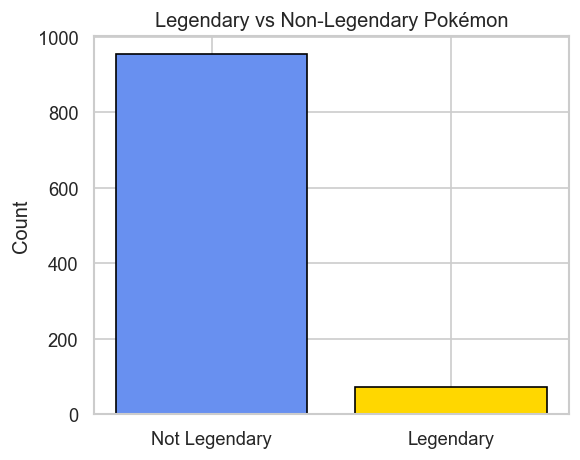

In [6]:
legendary_counts = df['is_legendary'].value_counts()
print(legendary_counts)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Not Legendary', 'Legendary'], legendary_counts.values,
       color=['#6890F0', '#FFD700'], edgecolor='black')
ax.set_title('Legendary vs Non-Legendary Pokémon')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Univariate Analysis — Generation

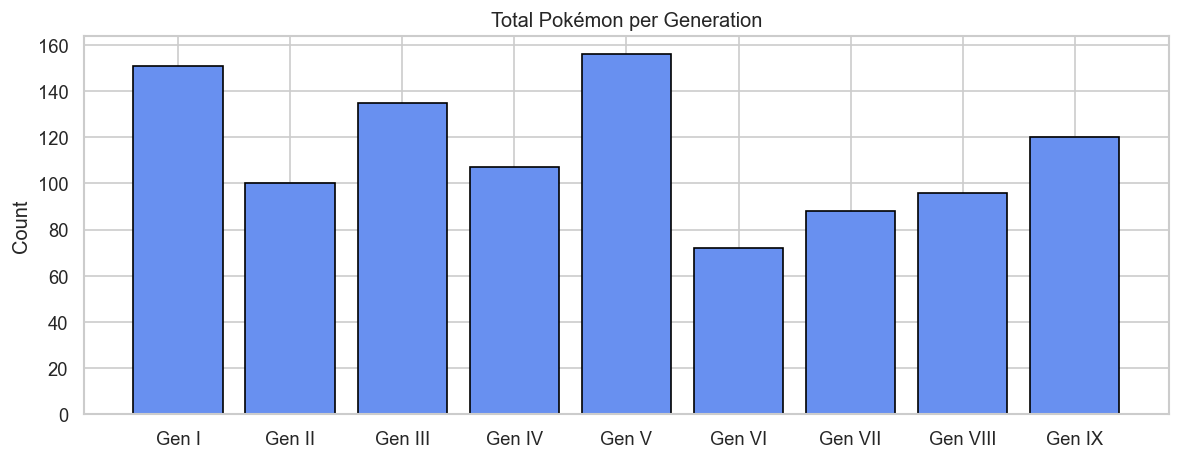

In [7]:
# Clean up generation label for readability
gen_order = [
    'generation-i', 'generation-ii', 'generation-iii', 'generation-iv',
    'generation-v', 'generation-vi', 'generation-vii', 'generation-viii', 'generation-ix'
]
gen_labels = ['Gen I', 'Gen II', 'Gen III', 'Gen IV', 'Gen V', 'Gen VI', 'Gen VII', 'Gen VIII', 'Gen IX']

total_per_gen = df['generation'].value_counts().reindex(gen_order)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(gen_labels, total_per_gen.values, color='#6890F0', edgecolor='black')
ax.set_title('Total Pokémon per Generation')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 4. Bivariate Analysis — Legendary Count per Generation (the core question!)

In [8]:
legendary_df = df[df['is_legendary'] == True]

leg_per_gen = legendary_df['generation'].value_counts().reindex(gen_order).fillna(0).astype(int)

print('Legendary Pokémon per Generation:')
for label, count in zip(gen_labels, leg_per_gen.values):
    print(f'  {label}: {count}')

print(f"\n🏆 Generation with the most legendaries: {gen_labels[leg_per_gen.values.argmax()]} ({leg_per_gen.values.max()})")

Legendary Pokémon per Generation:
  Gen I: 4
  Gen II: 5
  Gen III: 8
  Gen IV: 9
  Gen V: 9
  Gen VI: 3
  Gen VII: 11
  Gen VIII: 11
  Gen IX: 11

🏆 Generation with the most legendaries: Gen VII (11)


C:\Users\lendi\AppData\Local\Temp\ipykernel_13344\2016782277.py:23: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lendi\AppData\Local\Temp\ipykernel_13344\2016782277.py:24: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.savefig('../data/legendaries_per_generation.png', bbox_inches='tight')
c:\Users\lendi\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


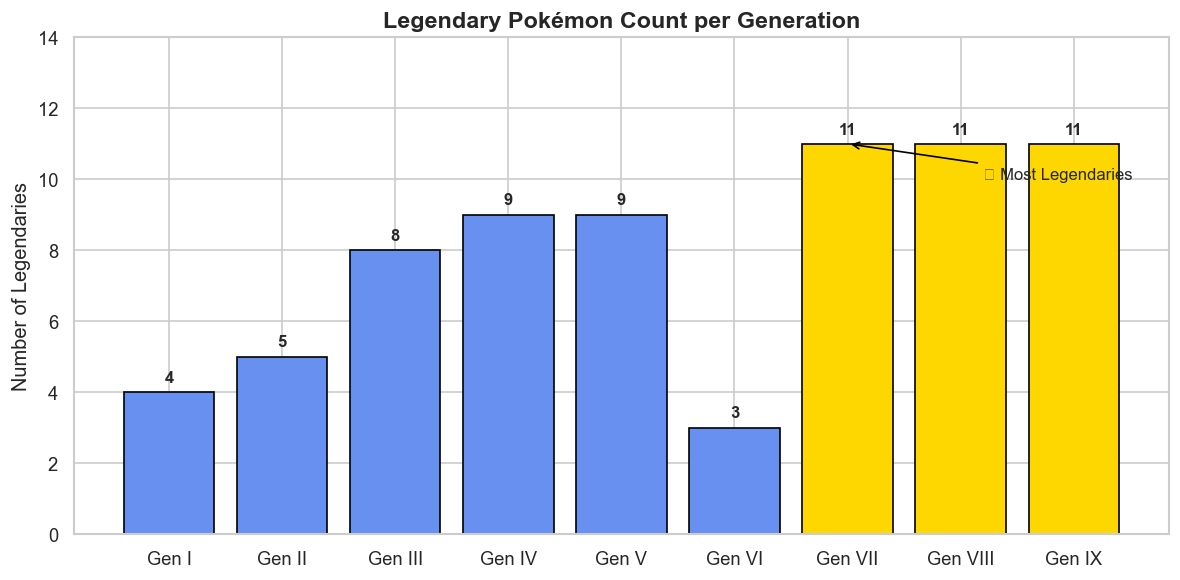

Chart saved to data/legendaries_per_generation.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#FFD700' if v == leg_per_gen.max() else '#6890F0' for v in leg_per_gen.values]
bars = ax.bar(gen_labels, leg_per_gen.values, color=colors, edgecolor='black')

# Label each bar
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.2, str(int(h)),
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Legendary Pokémon Count per Generation', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Legendaries')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0, leg_per_gen.max() + 3)

# Add a gold star annotation on the winning bar
winner_idx = leg_per_gen.values.argmax()
ax.annotate('⭐ Most Legendaries', xy=(winner_idx, leg_per_gen.values[winner_idx]),
            xytext=(winner_idx + 1.2, leg_per_gen.values[winner_idx] - 1),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

plt.tight_layout()
plt.savefig('../data/legendaries_per_generation.png', bbox_inches='tight')
plt.show()
print('Chart saved to data/legendaries_per_generation.png')

## 5. Percentage of Legendaries per Generation
To account for the fact that some generations introduced more Pokémon overall.

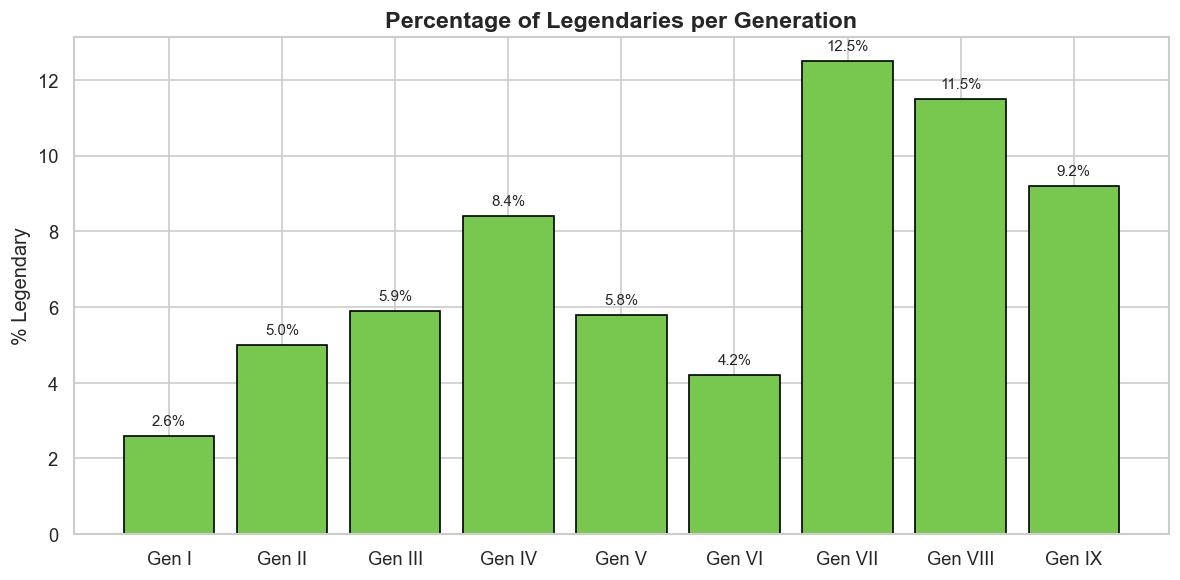

In [10]:
pct_legendary = (leg_per_gen / total_per_gen * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(gen_labels, pct_legendary.values, color='#78C850', edgecolor='black')

for bar, val in zip(ax.patches, pct_legendary.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{val}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Percentage of Legendaries per Generation', fontsize=14, fontweight='bold')
ax.set_ylabel('% Legendary')
plt.tight_layout()
plt.show()

## 6. Bonus — Other Independent Variables vs is_legendary

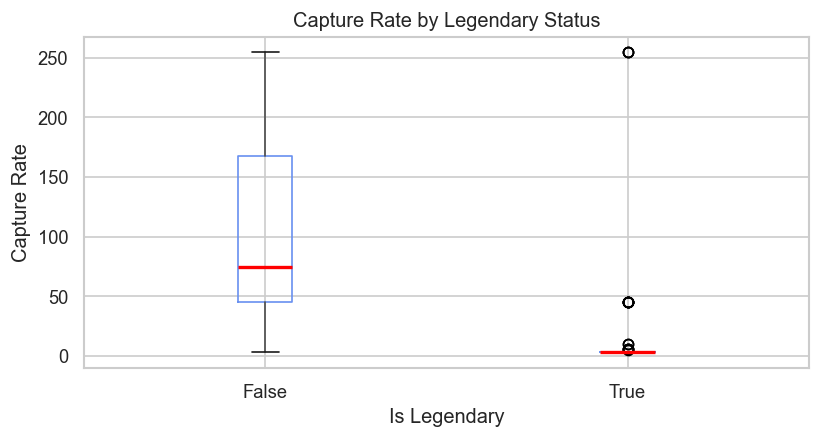

In [11]:
# Capture rate: legendary Pokémon should be harder to catch (lower capture rate)
fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column='capture_rate', by='is_legendary', ax=ax,
           boxprops=dict(color='#6890F0'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Capture Rate by Legendary Status')
ax.set_xlabel('Is Legendary')
ax.set_ylabel('Capture Rate')
plt.suptitle('')   # remove auto title
plt.tight_layout()
plt.show()

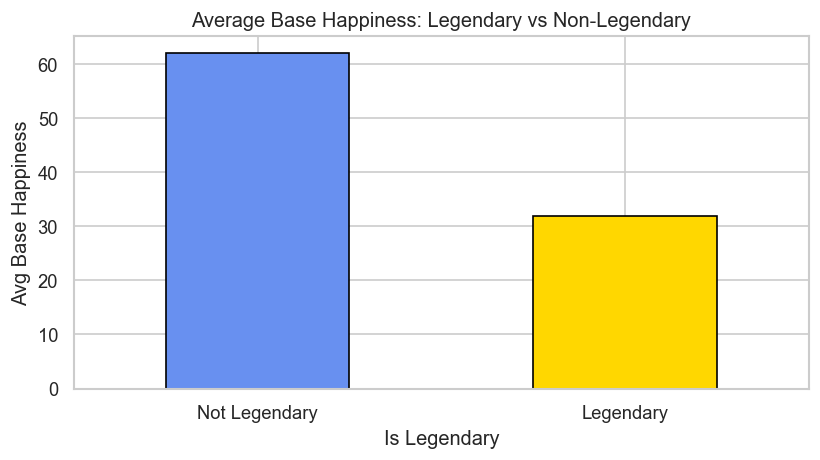

In [12]:
# Base happiness comparison
fig, ax = plt.subplots(figsize=(7, 4))
df.groupby('is_legendary')['base_happiness'].mean().plot(
    kind='bar', ax=ax, color=['#6890F0', '#FFD700'], edgecolor='black')
ax.set_title('Average Base Happiness: Legendary vs Non-Legendary')
ax.set_xlabel('Is Legendary')
ax.set_ylabel('Avg Base Happiness')
ax.set_xticklabels(['Not Legendary', 'Legendary'], rotation=0)
plt.tight_layout()
plt.show()

## 7. Summary & Findings

- **Total legendaries found:** 71 out of 1,025 Pokémon (6.9% of all species)
- **Generation with the most legendaries:** Gen VII, Gen VIII, and Gen IX all tied at **11 legendaries each**; Gen VII wins on proportion at **12.5%** of its species being legendary
- **Highest % legendary:** Gen VII at **12.5%** — meaning 1 in every 8 Gen VII Pokémon is legendary
- **Capture rate observation:** Legendary Pokémon have a mean capture rate of **18.2** (median **3.0**) vs **101.2** (median 75.0) for non-legendaries — confirming they are dramatically harder to catch
- **Base happiness observation:** Legendary Pokémon average **31.8** base happiness vs **62.0** for non-legendaries — legendaries start out noticeably less happy
- **Growth rate:** Every single legendary (100%) has the **"slow" growth rate**, meaning they require the most experience to level up
- **Egg group:** Every single legendary (100%) belongs to the **"no-eggs"** egg group — they cannot breed at all

These findings suggest that Gen VII is the most legend-dense generation, and legendary Pokémon share a tight biological profile: universally slow-growing, unable to breed, very hard to catch, and starting with low happiness.

## 8. Deep Dive — 12 Independent Variables vs is_legendary

### 8a. Growth Rate

                     Not Legendary  Legendary  % Legendary
growth_rate                                               
slow                           184         71         27.8
fast                            67          0          0.0
fast-then-very-slow             14          0          0.0
medium                         399          0          0.0
medium-slow                    261          0          0.0
slow-then-very-fast             29          0          0.0


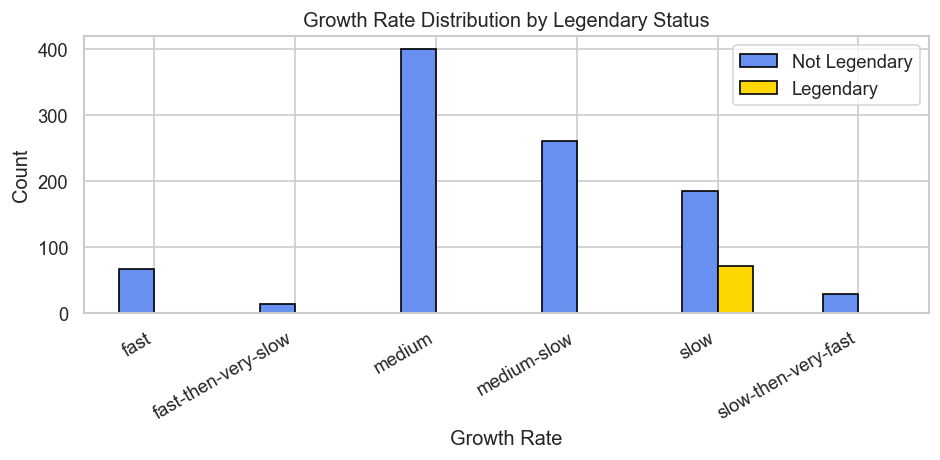

In [15]:
growth_leg = df.groupby(['growth_rate', 'is_legendary']).size().unstack(fill_value=0)
growth_leg.columns = ['Not Legendary', 'Legendary']
growth_leg['% Legendary'] = (growth_leg['Legendary'] / growth_leg.sum(axis=1) * 100).round(1)
print(growth_leg.sort_values('Legendary', ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
growth_leg[['Not Legendary', 'Legendary']].plot(kind='bar', ax=ax,
    color=['#6890F0', '#FFD700'], edgecolor='black')
ax.set_title('Growth Rate Distribution by Legendary Status')
ax.set_xlabel('Growth Rate')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../results/growth_rate_vs_legendary.png', bbox_inches='tight')
plt.show()

### 8b. Color

        Not Legendary  Legendary  % Legendary
color                                        
blue              156         14          8.2
red                89          8          8.2
black              44          7         13.7
gray              100          7          6.5
white              81          7          8.0
green             123          7          5.4
yellow             81          7          8.0
brown             141          6          4.1
purple             82          5          5.7
pink               57          3          5.0


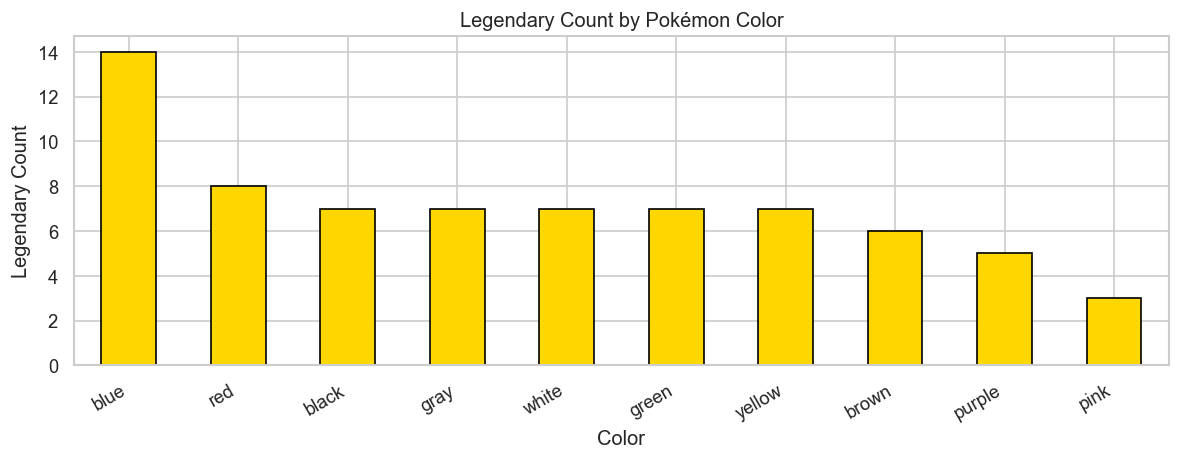

In [17]:
color_leg = df.groupby(['color', 'is_legendary']).size().unstack(fill_value=0)
color_leg.columns = ['Not Legendary', 'Legendary']
color_leg['% Legendary'] = (color_leg['Legendary'] / color_leg.sum(axis=1) * 100).round(1)
print(color_leg.sort_values('Legendary', ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
color_leg['Legendary'].sort_values(ascending=False).plot(kind='bar', ax=ax,
    color='#FFD700', edgecolor='black')
ax.set_title('Legendary Count by Pokémon Color')
ax.set_xlabel('Color')
ax.set_ylabel('Legendary Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../results/color_vs_legendary.png', bbox_inches='tight')
plt.show()

### 8c. Shape

           Not Legendary  Legendary  % Legendary
shape                                           
arms                  39          9         18.8
wings                 75         12         13.8
quadruped            180         20         10.0
squiggle              36          4         10.0
humanoid             145         10          6.5
upright              205         11          5.1
fish                  45          2          4.3
tentacles             23          1          4.2
ball                  49          2          3.9
armor                 46          0          0.0
bug-wings             22          0          0.0
blob                  41          0          0.0
legs                  28          0          0.0
heads                 20          0          0.0


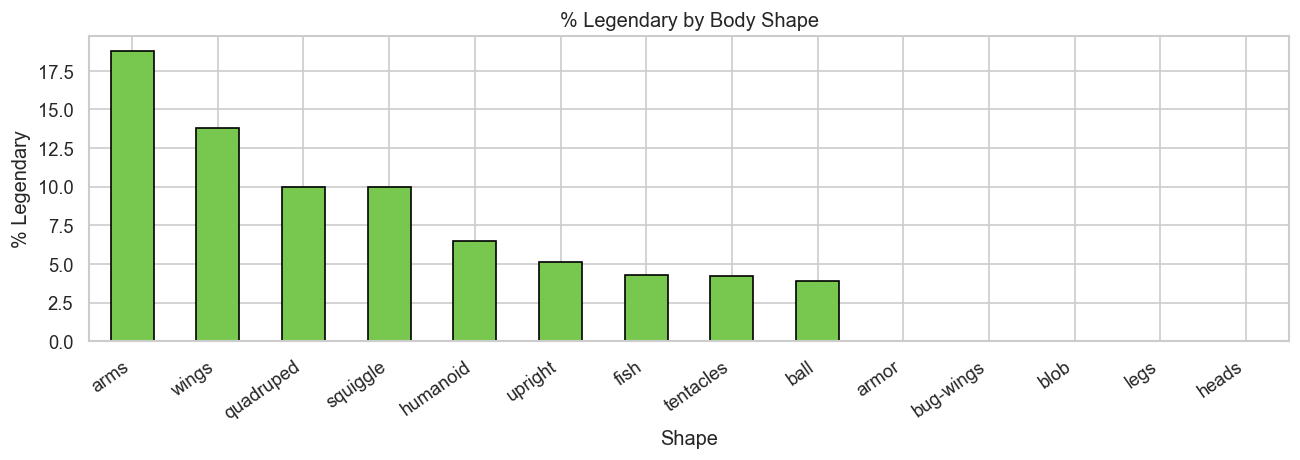

In [16]:
shape_leg = df.groupby(['shape', 'is_legendary']).size().unstack(fill_value=0)
shape_leg.columns = ['Not Legendary', 'Legendary']
shape_leg['% Legendary'] = (shape_leg['Legendary'] / shape_leg.sum(axis=1) * 100).round(1)
print(shape_leg.sort_values('% Legendary', ascending=False))

fig, ax = plt.subplots(figsize=(11, 4))
shape_leg['% Legendary'].sort_values(ascending=False).plot(kind='bar', ax=ax,
    color='#78C850', edgecolor='black')
ax.set_title('% Legendary by Body Shape')
ax.set_xlabel('Shape')
ax.set_ylabel('% Legendary')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.savefig('../results/shape_vs_legendary.png', bbox_inches='tight')
plt.show()

### 8d. Habitat

               Not Legendary  Legendary  % Legendary
habitat                                             
rare                       3          7         70.0
cave                      26          3         10.3
waters-edge               45          2          4.3
grassland                 77          3          3.8
rough-terrain             26          1          3.7
sea                       39          1          2.5
forest                    71          0          0.0
mountain                  45          0          0.0
urban                     37          0          0.0


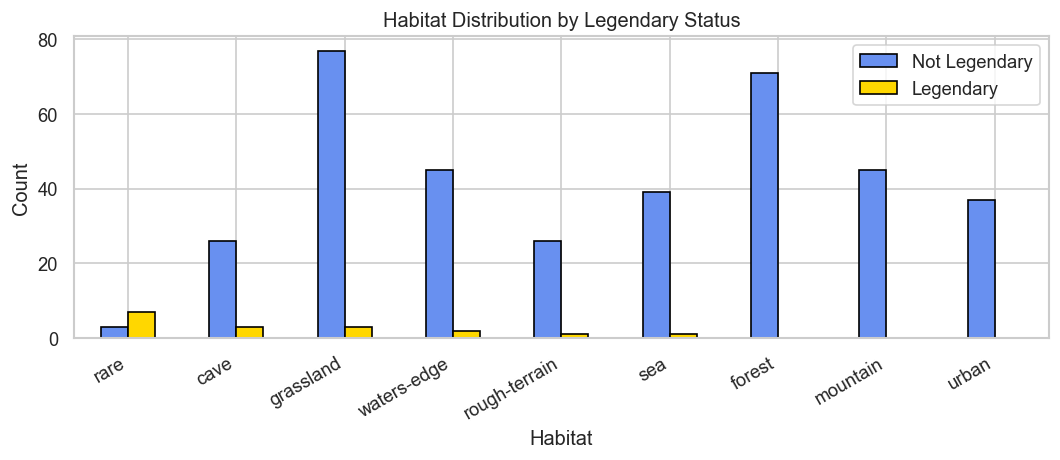

In [18]:
hab_leg = df.groupby(['habitat', 'is_legendary']).size().unstack(fill_value=0)
hab_leg.columns = ['Not Legendary', 'Legendary']
hab_leg['% Legendary'] = (hab_leg['Legendary'] / hab_leg.sum(axis=1) * 100).round(1)
print(hab_leg.sort_values('% Legendary', ascending=False))

fig, ax = plt.subplots(figsize=(9, 4))
hab_leg[['Not Legendary', 'Legendary']].sort_values('Legendary', ascending=False).plot(
    kind='bar', ax=ax, color=['#6890F0', '#FFD700'], edgecolor='black')
ax.set_title('Habitat Distribution by Legendary Status')
ax.set_xlabel('Habitat')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../results/habitat_vs_legendary.png', bbox_inches='tight')
plt.show()

### 8e. Egg Groups

               Not Legendary  Legendary  % Legendary
egg_group_1                                         
no-eggs                   80         71         47.0
ditto                      1          0          0.0
bug                       87          0          0.0
fairy                     43          0          0.0
flying                    64          0          0.0
ground                   238          0          0.0
dragon                    16          0          0.0
humanshape                46          0          0.0
indeterminate             43          0          0.0
mineral                   66          0          0.0
monster                   80          0          0.0
plant                     51          0          0.0
water1                    96          0          0.0
water2                    24          0          0.0
water3                    19          0          0.0


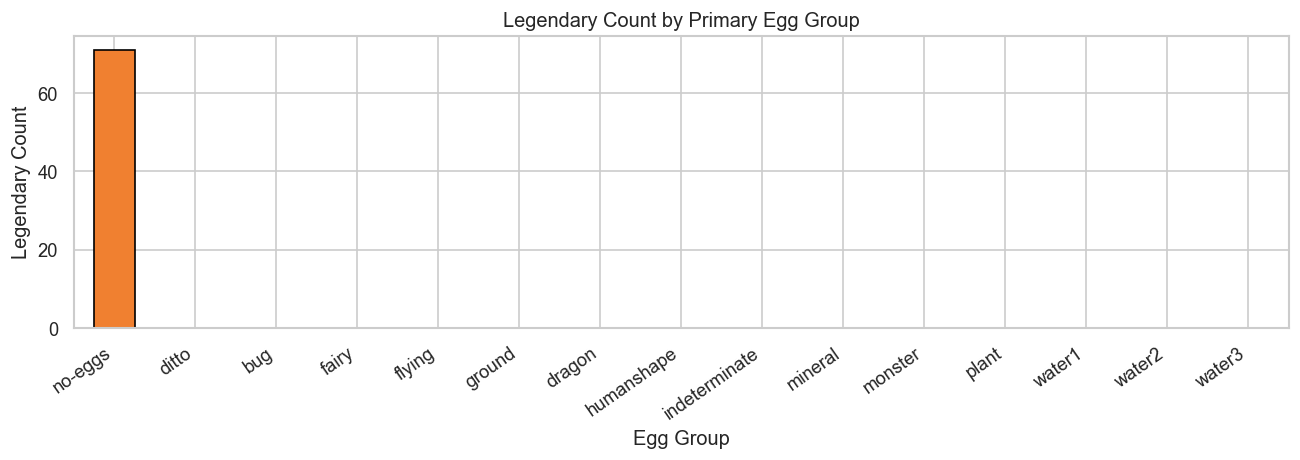

In [19]:
egg_leg = df.groupby(['egg_group_1', 'is_legendary']).size().unstack(fill_value=0)
egg_leg.columns = ['Not Legendary', 'Legendary']
egg_leg['% Legendary'] = (egg_leg['Legendary'] / egg_leg.sum(axis=1) * 100).round(1)
print(egg_leg.sort_values('Legendary', ascending=False))

fig, ax = plt.subplots(figsize=(11, 4))
egg_leg['Legendary'].sort_values(ascending=False).plot(kind='bar', ax=ax,
    color='#F08030', edgecolor='black')
ax.set_title('Legendary Count by Primary Egg Group')
ax.set_xlabel('Egg Group')
ax.set_ylabel('Legendary Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.savefig('../results/egg_group_vs_legendary.png', bbox_inches='tight')
plt.show()

### 8f. Hatch Counter

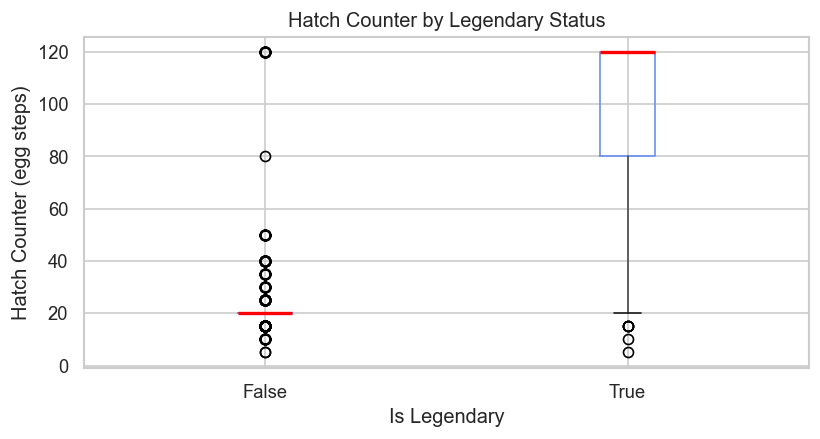

is_legendary
False    24.9
True     91.2
Name: hatch_counter, dtype: float64


In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column='hatch_counter', by='is_legendary', ax=ax,
           boxprops=dict(color='#6890F0'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Hatch Counter by Legendary Status')
ax.set_xlabel('Is Legendary')
ax.set_ylabel('Hatch Counter (egg steps)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('../results/hatch_counter_vs_legendary.png', bbox_inches='tight')
plt.show()

print(df.groupby('is_legendary')['hatch_counter'].mean().round(1))

### 8g. is_mythical / is_baby / has_gender_differences

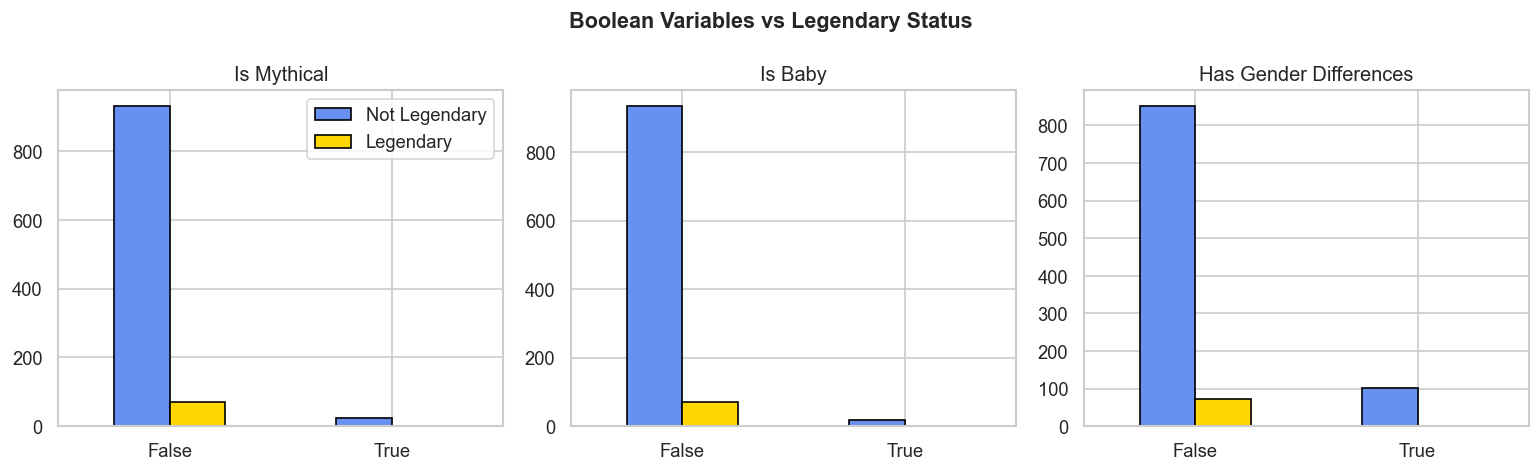

In [21]:
bool_vars = ['is_mythical', 'is_baby', 'has_gender_differences']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, bool_vars):
    ct = df.groupby([col, 'is_legendary']).size().unstack(fill_value=0)
    ct.columns = ['Not Legendary', 'Legendary']
    ct.plot(kind='bar', ax=ax, color=['#6890F0', '#FFD700'], edgecolor='black', legend=(col == bool_vars[0]))
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_xticklabels(['False', 'True'], rotation=0)
plt.suptitle('Boolean Variables vs Legendary Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/boolean_vars_vs_legendary.png', bbox_inches='tight')
plt.show()

## 9. Conclusion

**Research Question:** How many Legendary Pokémon are there in each generation, and which generation has the most?

**Answer:** Gen VII, VIII, and IX each introduced **11 legendaries** — the highest raw count. Gen VII stands out further with the **highest proportion at 12.5%** of its species being legendary.

**Key Patterns Across Independent Variables:**
- **Growth rate:** 100% of all legendary Pokémon use the "slow" growth rate — the hardest rate to level up
- **Egg group:** 100% belong to "no-eggs" — legendaries cannot breed, making them truly one-of-a-kind
- **Capture rate:** Legendary Pokémon are ~5.5× harder to catch on average (mean 18.2 vs 101.2)
- **Base happiness:** Legendaries start significantly less happy (31.8 vs 62.0)
- **Color:** Blue is the most common legendary color (14 out of 71), but the distribution is broad
- **Habitat:** Most legendaries with habitat data are classified as "rare" — reinforcing their scarcity
- **Has gender differences:** Legendaries almost never have gender differences, consistent with being genderless

**Bottom line:** Legendary Pokémon form a biologically distinct group — they are slow-leveling, unbreedable, hard to catch, and introduced in increasing numbers as the series has matured.